In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# -------------------------
# Base Generators
# -------------------------

def generate_trend(T, d):
    t = np.linspace(0, 1, T)
    slope = np.random.uniform(1.0, 3.0)
    base = slope * t
    
    X = np.zeros((T, d))
    for j in range(d):
        X[:, j] = base + np.random.normal(0, 0.05, T)
    
    return X


def generate_sine(T, d):
    t = np.linspace(0, 1, T)
    X = np.zeros((T, d))
    
    for j in range(d):
        freq = np.random.uniform(2, 5)
        phase = np.random.uniform(0, 2*np.pi)
        X[:, j] = np.sin(2 * np.pi * freq * t + phase)
        X[:, j] += np.random.normal(0, 0.05, T)
    
    return X


def generate_ar(T, d):
    X = np.zeros((T, d))
    
    for j in range(d):
        phi = np.random.uniform(0.6, 0.9)
        noise = np.random.normal(0, 0.1, T)
        
        for t in range(1, T):
            X[t, j] = phi * X[t-1, j] + noise[t]
    
    return X


# -------------------------
# Anomaly Injection
# -------------------------

def inject_trend_anomaly(X, start, length):
    # reverse slope locally
    for t in range(start, start + length):
        X[t] -= (1.25 * (X[t] - X[start]) **2) + 0.5 * (X[t] - X[start]) 
    return X


def inject_sine_anomaly(X, start, length):
    # distort frequency locally
    for j in range(X.shape[1]):
        t = np.arange(length)
        X[start:start+length, j] = np.sin(5 * t / length)  # higher freq
    return X


def inject_ar_anomaly(X, start, length):
    # break temporal dependency
    noise = np.random.normal(0, 0.25, (length, X.shape[1]))
    X[start:start+length] = noise
    return X


# -------------------------
# Main Dataset Generator
# -------------------------

def generate_dataset(T=1599, d=15, anomaly_length=25):
    segment_length = T // 3
    
    # Generate regimes
    X1 = generate_trend(segment_length, d)
    X2 = generate_sine(segment_length, d)
    X3 = generate_ar(segment_length, d)
    
    # Concatenate
    X = np.vstack([X1, X2, X3])
    
    # Labels
    y = np.zeros(T)
    
    # Inject anomalies
    starts = [
        np.random.randint(250, 350),
        np.random.randint(650, 800),
        np.random.randint(1450, 1550)
    ]
    
    X = inject_trend_anomaly(X, starts[0], anomaly_length)
    X = inject_sine_anomaly(X, starts[1], anomaly_length)
    X = inject_ar_anomaly(X, starts[2], anomaly_length)
    
    for s in starts:
        y[s:s+anomaly_length] = 1
    
    # Regime labels (for analysis, not training)
    regimes = np.concatenate([
        np.zeros(segment_length),
        np.ones(segment_length),
        2 * np.ones(segment_length)
    ])
    
    return X, y, regimes

In [ ]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(5, 1, figsize=(12, 6), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(5):
        axes[j].plot(t, X[:, j])
        
        # Highlight anomalies
        anomaly_idx = np.where(y == 1)[0]
        axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

In [27]:
# -------------------------
# Base Generators
# -------------------------

def generate_trend(T):
    t = np.linspace(0, 1, T)
    a = np.random.uniform(5.0, 10.0)
    b = np.random.uniform(-5.0, 5.0)
    X = a * t**2 + b * t
    X += np.random.normal(0, 0.05, T)     
    return X


def generate_sine(T):
    t = np.linspace(0, 1, T)
    X = np.zeros((T))
    
    freq = np.random.uniform(2, 5)
    phase = np.random.uniform(0, 2*np.pi)
    X = np.sin(2 * np.pi * freq * t + phase)
    X += np.random.normal(0, 0.05, T)
    
    return X


def generate_ar(T):
    X = np.zeros((T))
    
    phi = np.random.uniform(0.6, 0.9)
    noise = np.random.normal(0, 0.1, T)
        
    for t in range(1, T):
        X[t] = phi * X[t-1] + noise[t]
    
    return X


# -------------------------
# Anomaly Injection
# -------------------------

def inject_trend_anomaly(X, start, length):
    # nonlinear local distortion
    for t in range(start, start + length):
        delta = X[t] - X[start]
        X[t] -= (0.25 * delta**2) + 0.75 * delta
    return X


def inject_sine_anomaly(X, start, length):
    # local frequency distortion
    t_local = np.arange(length)
    distorted = np.sin(2 * t_local / length)
    
    X[start:start+length] = distorted + np.random.normal(0, 0.05, length)
    return X


def inject_ar_anomaly(X, start, length):
    # break temporal dependency with higher variance noise
    noise = np.random.normal(0, 0.5, length)
    X[start:start+length] = noise
    return X


# -------------------------
# Main Dataset Generator
# -------------------------

def generate_dataset(T=1599, anomaly_length=25, type = 'Trend'):
    # Generate regimes
    if type == 'Trend':
        X = generate_trend(T)
    elif type == 'Sine':
        X = generate_sine(T)
    else:
        X = generate_ar(T)
    # Labels
    y = np.zeros(T)
    
    # Inject anomalies
    start = np.random.randint(1400, 1500)
    if type == 'Trend':
        X = inject_trend_anomaly(X, start, anomaly_length)
    elif type == 'Sine':
        X = inject_sine_anomaly(X, start, anomaly_length)  
    else:
        X = inject_ar_anomaly(X, start, anomaly_length)
    
    
    y[start:start+anomaly_length] = 1

    
    return X, y, start

1468


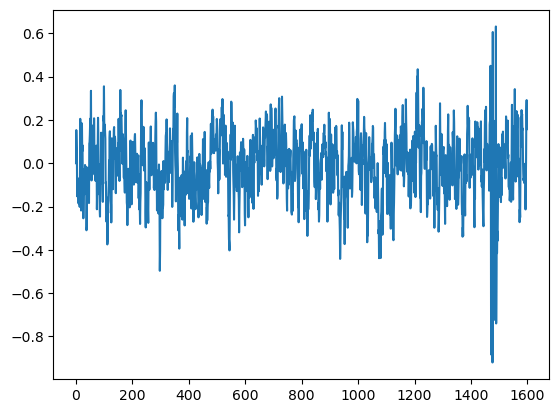

In [28]:
X,y,start = generate_dataset(type='AR')
print(start)
plt.plot(X)

In [30]:
#Use this exact convention from README.md:11:

# [index][DatasetName]id[id][Domain]tr[TrainIndex]1st[FirstAnomalyIndex].csv

# Example:
# 245_MyData_id_1_Sensor_tr_1200_1st_1530.csv

for i in range(10):
    X,y,start = generate_dataset(type='Sine')
    filename = f"{i+11}_SyntheticSine_id_{i}_Sensor_tr_1200_1st_{start}.csv"
    df = pd.DataFrame({'Value': X, 'Label': y})
    df.to_csv(filename, index=False)



In [115]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

# Generate data
X, y, regimes = generate_dataset()

# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.015,  # expected anomaly proportion
    random_state=42
)

iso.fit(X)

# Predict
preds = iso.predict(X)

# Convert predictions:
# sklearn: -1 = anomaly, 1 = normal
y_pred = (preds == -1).astype(int)

# Evaluate
print("Classification Report:")
print(classification_report(y, y_pred))

print("ROC-AUC:", roc_auc_score(y, -iso.decision_function(X)))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      1524
         1.0       0.21      0.07      0.10        75

    accuracy                           0.94      1599
   macro avg       0.58      0.53      0.54      1599
weighted avg       0.92      0.94      0.93      1599

ROC-AUC: 0.5122703412073492


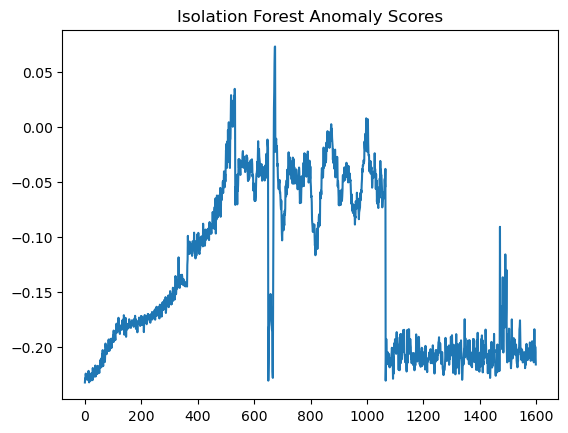

In [116]:
scores = -iso.decision_function(X)

import matplotlib.pyplot as plt
plt.plot(scores)
plt.title("Isolation Forest Anomaly Scores")
plt.show()

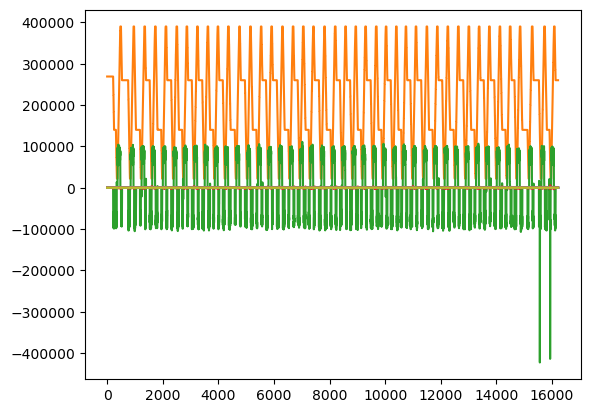

In [63]:
comparison = pd.read_csv("C:\\Users\\brand\\OneDrive\\Documents\\Time Series Project\\Anomaly-Detection-Thesis\\Benchmark CSVs\\001_Genesis_id_1_Sensor_tr_4055_1st_15538.csv")
plt.plot(comparison)

In [123]:
PSM = pd.read_csv("C:\\Users\\brand\\OneDrive\\Documents\\Time Series Project\\Anomaly-Detection-Thesis\\Benchmark CSVs\\115_PSM_id_1_Facility_tr_50000_1st_129872.csv")
PSM_train = PSM.drop(columns=['Label'])
# plt.plot(PSM)

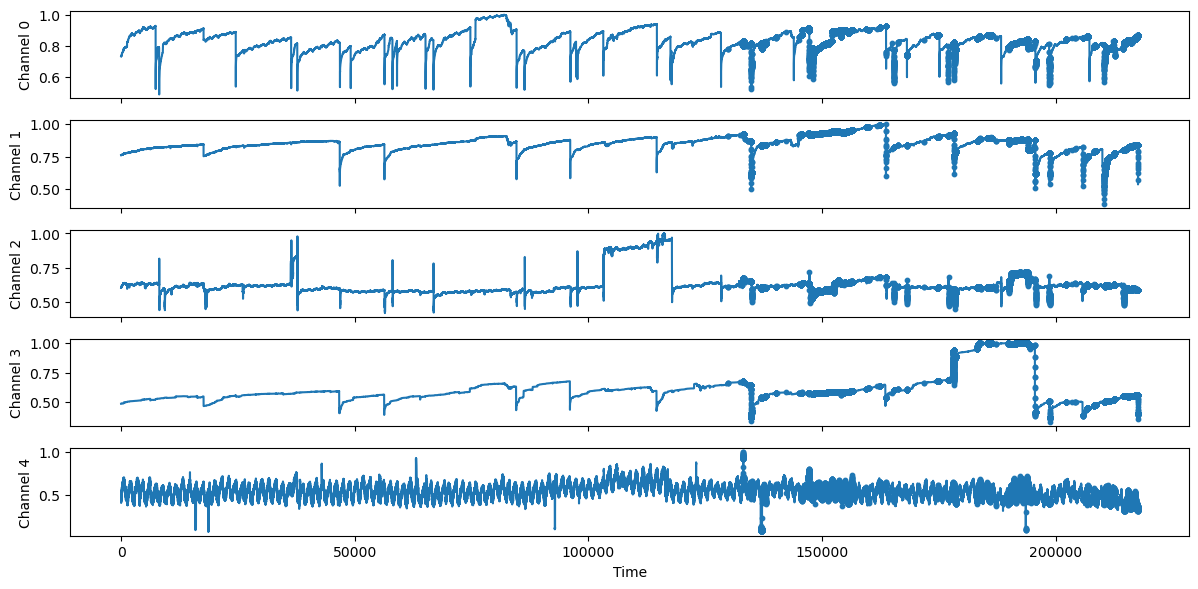

In [135]:
plot_mts(PSM_train.values, PSM['Label'].values)

In [64]:
comparison.head()

,MotorData.ActCurrent,MotorData.ActPosition,MotorData.ActSpeed,MotorData.IsAcceleration,MotorData.IsForce,MotorData.Motor_Pos1reached,MotorData.Motor_Pos2reached,MotorData.Motor_Pos3reached,MotorData.Motor_Pos4reached,NVL_Recv_Ind.GL_Metall,NVL_Recv_Ind.GL_NonMetall,NVL_Recv_Storage.GL_I_ProcessStarted,NVL_Recv_Storage.GL_I_Slider_IN,NVL_Recv_Storage.GL_I_Slider_OUT,NVL_Recv_Storage.GL_LightBarrier,NVL_Send_Storage.ActivateStorage,PLC_PRG.Gripper,PLC_PRG.MaterialIsMetal,Label
0,-5,268975,0,0,-1,0,0,0,0,0,1,0,1,0,1,0,0,0,0
1,0,268975,0,0,-1,0,0,0,0,0,1,0,1,0,1,0,0,0,0
2,-5,268975,0,0,-3,0,0,0,0,0,1,0,1,0,1,0,0,0,0
3,0,268975,0,0,4,0,0,0,0,0,1,0,1,0,1,0,0,0,0
4,0,268975,0,0,4,0,0,0,0,0,1,0,1,0,1,0,0,0,0


In [67]:
comparison_train = comparison.drop(columns=['Label'])
# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.015,  # expected anomaly proportion
    random_state=42
)

iso.fit(comparison_train)

# Predict
preds = iso.predict(comparison_train)

# Convert predictions:
# sklearn: -1 = anomaly, 1 = normal
y_pred = (preds == -1).astype(int)

# Evaluate
print("Classification Report:")
print(classification_report(comparison['Label'], y_pred))

print("ROC-AUC:", roc_auc_score(comparison['Label'], -iso.decision_function(comparison_train)))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     16170
           1       0.00      0.00      0.00        50

    accuracy                           0.98     16220
   macro avg       0.50      0.49      0.50     16220
weighted avg       0.99      0.98      0.99     16220

ROC-AUC: 0.7789041434755719


In [89]:
print(preds[preds == 1].sum())
print(preds[preds == -1].sum() * -1)
print(comparison['Label'].value_counts())
print(15676 + 224)

15976
244
Label
0    16170
1       50
Name: count, dtype: int64
15900
